# AECD model pipeline results

각 분석 구현을 다시 실행하고, 서로 다른 출력 schema를 하나의 `results` 테이블로 합치는 재현 가능한 실험 노트북입니다. 기존 숫자를 표에 직접 입력하지 않습니다.

## tl;dr

- `RUN_EXPERIMENTS=False`: 기존 산출물만 읽어 결과표를 재생성합니다.
- `RUN_EXPERIMENTS=True`: `SELECTED_EXPERIMENTS`의 기존 구현을 다시 실행한 뒤 결과표를 생성합니다.
- AECD API 실험에는 API와 PostgreSQL calibration 접근 환경변수가 필요합니다.
- ResNet 및 multimodal 실험은 GPU 사용 시에도 오래 걸릴 수 있습니다.

## Context & Methods

### 1. Setup

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
for candidate in (REPO_ROOT, *REPO_ROOT.parents):
    if (candidate / 'notebooks/aecd_model_results_registry.py').exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError('SERS-AI repository root was not found.')

NOTEBOOK_DIR = REPO_ROOT / 'notebooks'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from aecd_model_results_registry import (
    EXPERIMENTS,
    collect_results,
    experiment_catalog,
    interpretation_table,
    merge_binary_and_three_class,
    run_selected,
)

pd.set_option('display.max_colwidth', 100)
print({'repository': str(REPO_ROOT), 'experiment_count': len(EXPERIMENTS)})

{'repository': '\\\\wsl.localhost\\Ubuntu-24.04\\home\\user\\SERS-AI', 'experiment_count': 10}


### 2. Experiment registry

In [2]:
catalog = experiment_catalog()
display(catalog)

,key,family,title,output_dir,notes
0,aecd_direct_mean,AECD API,Current direct mean,\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\notebooks\aecd_api_model_mean_spectrum_outputs,PS alignment + repeat QC + subject mean; direct four-model stacking
1,aecd_dwt_and_raw,AECD API,DWT raw and DWT preprocessing,\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\notebooks\aecd_api_model_patent_dwt_outputs,Raw subject mean and residual DWT db4/AsLS evaluated with STK-V2
2,aecd_all_qc,AECD API,Current all-QC spectra,\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\notebooks\aecd_api_model_all_qc_spectra_outputs,All QC-passed repeats; subject-level probability aggregation
3,aecd_three_class,AECD API,AECD three-class conditions,\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\notebooks\aecd_api_model_3class_outputs,"Direct mean, raw STK-V2, DWT STK-V2, and all-QC three-class runs"
4,mapping_resnet_3,Mapping Raman,Spectrum LR-reference and ResNet 3-block,\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\results\notebook_resnet_3,Standard Raman preprocessing; LR reference and 3-block ResNet
5,mapping_resnet_6,Mapping Raman,ResNet 6-block,\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\results\notebook_resnet_6,Standard Raman preprocessing; 6-block ResNet
6,mapping_resnet_9,Mapping Raman,ResNet 9-block,\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\results\notebook_resnet_9,Standard Raman preprocessing; 9-block ResNet
7,mapping_position_aware,Mapping Raman,Position-aware ResNet pilot,\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\results\notebook_position_aware,Absolute Raman position channel added to the 3-block ResNet
8,mapping_clinical,Mapping multimodal,Clinical-only LR and Clinical-input CNN,\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\results\notebook_clinical,"Clinical-only LR, spectrum controls, and clinical-input CNN on identical folds"
9,mapping_clinical_spectrum_lr,Mapping multimodal,Clinical + Spectrum LR,\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\results\notebook_clinical_spectrum_lr,Patient-mean spectrum concatenated with five clinical variables


### Key assumptions

- 각 실험은 원래 구현의 split, preprocessing 및 모델 설정을 보존합니다.
- 따라서 이 표는 완전히 통제된 단일-factor ablation이 아니라 end-to-end pipeline 비교입니다.
- Mapping Raman/clinical 실험과 AECD API 실험은 데이터 계보가 다를 수 있으므로 `family`를 유지합니다.
- locked external 결과는 nested OOF와 별도로 취급해야 합니다.

## Data

### 3. Select and optionally rerun experiments

In [3]:
RUN_EXPERIMENTS = False

SELECTED_EXPERIMENTS = [
    'aecd_direct_mean',
    'aecd_dwt_and_raw',
    'aecd_all_qc',
    'aecd_three_class',
    'mapping_resnet_3',
    'mapping_resnet_6',
    'mapping_resnet_9',
    'mapping_position_aware',
    'mapping_clinical',
    'mapping_clinical_spectrum_lr',
]

if RUN_EXPERIMENTS:
    run_selected(SELECTED_EXPERIMENTS)
else:
    print('Collection-only mode: existing output files will be used.')

Collection-only mode: existing output files will be used.


### 4. Dependency-aware rerun examples

Clinical-input CNN과 Clinical + Spectrum LR은 3-block ResNet 산출물에 의존하므로 아래 순서로 실행합니다. 필요한 계열만 선택해 실행할 수 있습니다.

In [4]:
# Example: Raman-only AECD pipelines
# run_selected(['aecd_direct_mean', 'aecd_dwt_and_raw', 'aecd_all_qc', 'aecd_three_class'])

# Example: mapping Raman → clinical fusion dependency chain
# run_selected(['mapping_resnet_3', 'mapping_clinical', 'mapping_clinical_spectrum_lr'])

# Example: CNN depth comparison
# run_selected(['mapping_resnet_3', 'mapping_resnet_6', 'mapping_resnet_9'])

## Results

### 5. Collect standardized results

In [5]:
raw_results = collect_results(SELECTED_EXPERIMENTS)
results = merge_binary_and_three_class(raw_results)
results = interpretation_table(results)

metric_columns = [
    'binary_auc', 'binary_bacc', 'macro_auc_3class', 'bacc_3class',
    'macro_f1_3class', 'control_auc', 'pdc_auc', 'cancer_auc',
]
display(results.style.format({column: '{:.4f}' for column in metric_columns}, na_rep='-'))
print({'collected_rows': len(raw_results), 'merged_conditions': len(results)})

,experiment_key,family,condition,model,binary_auc,binary_bacc,macro_auc_3class,bacc_3class,macro_f1_3class,control_auc,pdc_auc,cancer_auc,evaluation,notes,interpretation
0,"aecd_direct_mean, aecd_three_class",AECD API,Current direct mean,direct_qc_passed_mean_spectrum_stacking | STK-V2 or direct stacking (condition-specific),0.6625,0.6264,0.5459,0.3979,0.3627,0.3701,0.5842,0.6834,nested subject-level OOF,"PS alignment + repeat QC + subject mean; direct four-model stacking | Direct mean, raw STK-V2, DWT STK-V2, and all-QC three-class runs",
1,"aecd_dwt_and_raw, aecd_three_class",AECD API,DWT raw comparison,Existing raw subject-mean | STK-V2 or direct stacking (condition-specific),0.7163,0.6711,0.6595,0.4406,0.3980,0.6630,0.6260,0.6894,nested subject-level OOF,"Raw subject mean and residual DWT db4/AsLS evaluated with STK-V2 | Direct mean, raw STK-V2, DWT STK-V2, and all-QC three-class runs",Highest binary AUC. Highest three-class macro AUC.
2,"aecd_dwt_and_raw, aecd_three_class",AECD API,DWT preprocessing,Patent DWT preprocessing | STK-V2 or direct stacking (condition-specific),0.5233,0.5307,0.4523,0.2453,0.2419,0.4953,0.4094,0.4522,nested subject-level OOF,"Raw subject mean and residual DWT db4/AsLS evaluated with STK-V2 | Direct mean, raw STK-V2, DWT STK-V2, and all-QC three-class runs",Compare directly with the DWT raw control.
3,"aecd_all_qc, aecd_three_class",AECD API,Current all-QC spectra,all_qc_passed_aligned_spectra_with_subject_level_aggregation | Direct stacking on all QC-passed spectra with subject aggregation,0.5957,0.5566,0.5547,0.3718,0.3326,0.4436,0.6055,0.6150,nested subject-level OOF,"All QC-passed repeats; subject-level probability aggregation | Direct mean, raw STK-V2, DWT STK-V2, and all-QC three-class runs",


{'collected_rows': 8, 'merged_conditions': 4}


### 6. Save reproducible comparison table

In [6]:
OUTPUT_DIR = NOTEBOOK_DIR / 'aecd_model_pipeline_results_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results_path = OUTPUT_DIR / 'model_pipeline_comparison.csv'
results.to_csv(results_path, index=False, encoding='utf-8-sig')
print(results_path)

\\wsl.localhost\Ubuntu-24.04\home\user\SERS-AI\notebooks\aecd_model_pipeline_results_outputs\model_pipeline_comparison.csv


### 7. Plot performance by model family

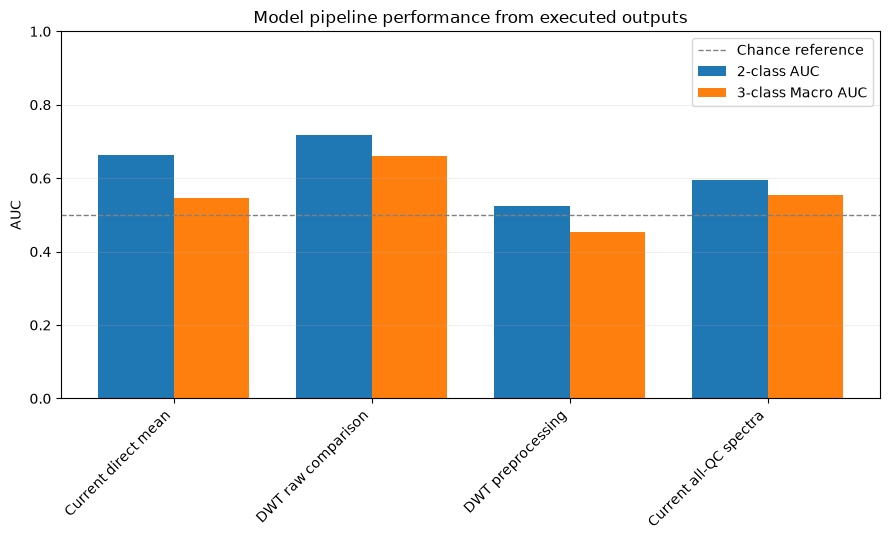

In [7]:
plot_frame = results[['family', 'condition', 'binary_auc', 'macro_auc_3class']].copy()
plot_frame = plot_frame.loc[plot_frame[['binary_auc', 'macro_auc_3class']].notna().any(axis=1)]

if len(plot_frame):
    positions = np.arange(len(plot_frame))
    width = 0.38
    fig, axis = plt.subplots(figsize=(max(9, len(plot_frame) * 0.8), 5.5))
    axis.bar(positions - width / 2, plot_frame['binary_auc'], width, label='2-class AUC')
    axis.bar(positions + width / 2, plot_frame['macro_auc_3class'], width, label='3-class Macro AUC')
    axis.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance reference')
    axis.set_xticks(positions, plot_frame['condition'], rotation=45, ha='right')
    axis.set_ylim(0, 1)
    axis.set_ylabel('AUC')
    axis.set_title('Model pipeline performance from executed outputs')
    axis.grid(axis='y', alpha=0.2)
    axis.legend()
    fig.tight_layout()
    figure_path = OUTPUT_DIR / 'model_pipeline_auc_comparison.png'
    fig.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('No result files were found. Set RUN_EXPERIMENTS=True or check the output paths.')

## Takeaways

이 노트북의 결론은 실행된 `results`에서만 작성해야 합니다. 서로 다른 데이터 계열은 `family`별로 먼저 비교하고, 동일 계열 안에서 raw/DWT, mean/all-QC, LR/ResNet, clinical-only/fusion 변화를 해석합니다.

In [8]:
if len(results):
    for family, family_frame in results.groupby('family'):
        print(f'[{family}]')
        if family_frame['binary_auc'].notna().any():
            best = family_frame.loc[family_frame['binary_auc'].idxmax()]
            print(f"  best binary AUC: {best['condition']} = {best['binary_auc']:.4f}")
        if family_frame['macro_auc_3class'].notna().any():
            best = family_frame.loc[family_frame['macro_auc_3class'].idxmax()]
            print(f"  best 3-class Macro AUC: {best['condition']} = {best['macro_auc_3class']:.4f}")

[AECD API]
  best binary AUC: DWT raw comparison = 0.7163
  best 3-class Macro AUC: DWT raw comparison = 0.6595
